In [ ]:
Ruoling Jiang, Collin Chen, Erik Luukas Hurst
ruoling2, collinc4, erikh2

Task 0 - 1

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


Task 0 - 2

In [ ]:
data = pickle.load(open('delta_a100_gpu_xid_dataset.pkl', 'rb')) # load data from pickle file into a variable called data

date = "2024-03-10" #create a variable called date and assign it to the specified date "2024-03-10"

if date in data: #check if the date is in the file
    logs = data[date]  #if the date is in the file, assign the information for that date to a variable called logs

    total_errors = len(logs) #calculate the total nuumber of XID errors by getting the lengths of the list of logs
    print(f"Total XID errors on {date}: {total_errors}") # print the total number of XID errors corresponding to the specified date

    xids = set() #create an empty set to store unique XID values
    for entry in logs: #iterate through each entry in logs
        xids.add(entry['XID']) # add the XID value from each entry into the set
    unique_xids = sorted(xids) # sort the unique XID values and assign them to unique_xids
    
    print(f"Unique XIDs on {date}: {unique_xids}") # print the unique XID values corresponding to the specified date

Total XID errors on 2024-03-10: 87
Unique XIDs on 2024-03-10: [13, 31, 43, 45, 74, 119]


Task 0 - 3

In [ ]:
rows = [] # create an array to later convert into a dataframe

for date, logs in data.items(): #loop through all the dates and logs in the data
    for entry in logs: # loop through all the datapoints
        rows.append({ 
            "Date": date, "Datetime": entry["datetime"],"Timestamp": entry["timestamp"],"Node name": entry["node_name"],"Device ID": entry["device_id"],"XID": entry["XID"],"Tag": entry["Tag"]
        }) # format a datapoint and add it into the array


df = pd.DataFrame(rows) # convert the array into a dataframe
df = df.sort_values(by="Timestamp")


print(df.head().to_string(index=True))

         Date                          Datetime     Timestamp Node name   Device ID  XID                               Tag
0  2022-07-17  2022-07-17T10:27:27.422837-05:00  1.658072e+09   gpua088  0000:c7:00  119               119_GSP_RPC_timeout
1  2022-07-17  2022-07-17T10:29:29.304632-05:00  1.658072e+09   gpua048  0000:07:00   45        045_GPU_PREEMPTIVE_CLEANUP
2  2022-07-17  2022-07-17T11:03:11.093546-05:00  1.658074e+09   gpua001  0000:85:00   13  013_GPU_GRAPHIC_ENGINE_EXCEPTION
3  2022-07-17  2022-07-17T11:04:15.807907-05:00  1.658074e+09   gpua044  0000:85:00   13  013_GPU_GRAPHIC_ENGINE_EXCEPTION
4  2022-07-17  2022-07-17T11:10:53.818266-05:00  1.658074e+09   gpua045  0000:07:00   43        043_GPU_STOPPED_PROCESSING


Task 1 - 1

In [ ]:
print(df.head(10).to_string(index=True)) # prints the first 10 data rows

first = df.iloc[0] # get the first row
print("First timestamp (UNIX):", first["Timestamp"])
print(
    "First timestamp (human):",
    pd.to_datetime(first["Timestamp"], unit="s", utc= True) #convert the first timestamp from UNIX to human-readable format
)


         Date                          Datetime     Timestamp Node name   Device ID  XID                               Tag
0  2022-07-17  2022-07-17T10:27:27.422837-05:00  1.658072e+09   gpua088  0000:c7:00  119               119_GSP_RPC_timeout
1  2022-07-17  2022-07-17T10:29:29.304632-05:00  1.658072e+09   gpua048  0000:07:00   45        045_GPU_PREEMPTIVE_CLEANUP
2  2022-07-17  2022-07-17T11:03:11.093546-05:00  1.658074e+09   gpua001  0000:85:00   13  013_GPU_GRAPHIC_ENGINE_EXCEPTION
3  2022-07-17  2022-07-17T11:04:15.807907-05:00  1.658074e+09   gpua044  0000:85:00   13  013_GPU_GRAPHIC_ENGINE_EXCEPTION
4  2022-07-17  2022-07-17T11:10:53.818266-05:00  1.658074e+09   gpua045  0000:07:00   43        043_GPU_STOPPED_PROCESSING
5  2022-07-17  2022-07-17T11:16:30.534940-05:00  1.658075e+09   gpua001  0000:c7:00   13  013_GPU_GRAPHIC_ENGINE_EXCEPTION
6  2022-07-17  2022-07-17T11:27:40.849346-05:00  1.658075e+09   gpua001  0000:c7:00   13  013_GPU_GRAPHIC_ENGINE_EXCEPTION
7  2022-07-17  2

Task 1 - 2

In [ ]:
counts = df["XID"].value_counts() #count the occurrences of each unique value in the "XID" column
total = len(df)  #calculate the total number of rows in the DataFrame

print("P(XID=43) =", counts.get(43, 0) / total) # divide the count of XID 43 by the total number of rows to get probability of encountering XID 43
print("P(XID=119) =", counts.get(119, 0) / total) #divide the count of XID 119 by the total number of rows to get probability of encountering XID 119
print("The system is more likely to encounter user errors that cause XID 43 (P(XID=43) = 0.11687569714612182 > P(XID=119) = 0.017724515058356233)")

P(XID=43) = 0.11687569714612182
P(XID=119) = 0.017724515058356233
The system is more likely to encounter user errors that cause XID 43 (P(XID=43) = 0.11687569714612182 > P(XID=119) = 0.017724515058356233)


Task 1 - 3

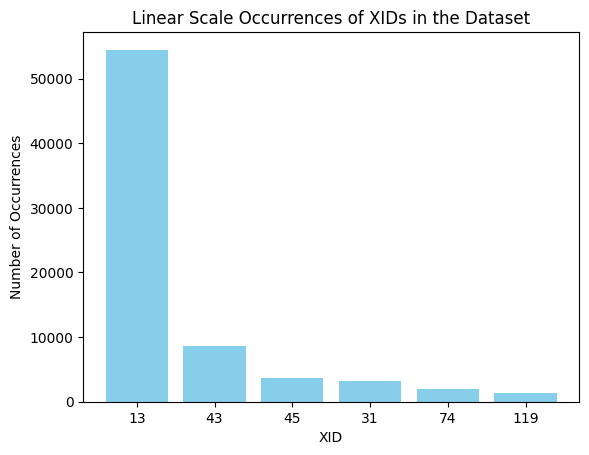

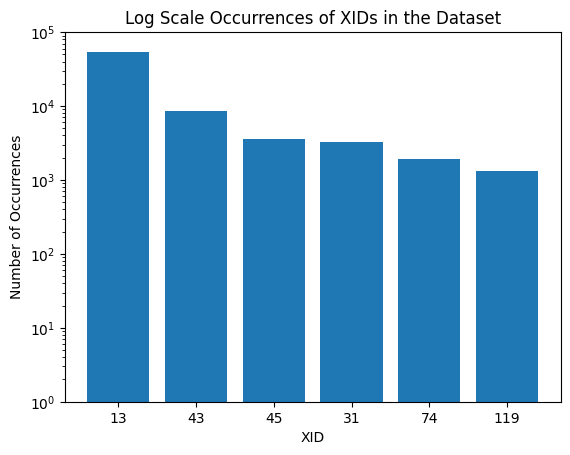

In [ ]:
XID = ['13', '43', '45','31', '74', '119'] # x axis labels
Number = [counts.get(13, 0), counts.get(43, 0), counts.get(45, 0), counts.get(31, 0), counts.get(74, 0), counts.get(119, 0)] # counts corresponding to the labels
plt.bar(XID, Number, color='skyblue') # set axis and color of the bars
plt.xlabel('XID') # set x axis label
plt.ylabel('Number of Occurrences') # set y axis label
plt.title('Linear Scale Occurrences of XIDs in the Dataset') # set title of the graph
plt.show() # show the graph

plt.bar(XID, Number, log=True) # set axis and color of the bars, set log scale for y axis
plt.xlabel('XID') # set x axis label
plt.ylabel('Number of Occurrences') # set y axis label
plt.yticks([1, 10, 100, 1000, 10000, 100000]) #set y axis ticks to be powers of 10
plt.title('Log Scale Occurrences of XIDs in the Dataset') # set title of the graph

plt.show() # show the graph


Task 1 - 4

In [ ]:
print("P(XID=13) =", counts.get(13, 0)) # get count of XID 13 and print it
print("P(XID=31) =", counts.get(31, 0)) # get count of XID 31 and print it
print("P(XID=43) =", counts.get(43, 0)) # get count of XID 43 and print it
print("P(XID=45) =", counts.get(45, 0)) # get count of XID 45 and print it
print("P(XID=74) =", counts.get(74, 0)) # get count of XID 74 and print it
print("P(XID=119) =", counts.get(119, 0)) # get count of XID 119 and print it


P(XID=13) = 54478
P(XID=31) = 3272
P(XID=43) = 8592
P(XID=45) = 3602
P(XID=74) = 1922
P(XID=119) = 1303


Task 1 - 5

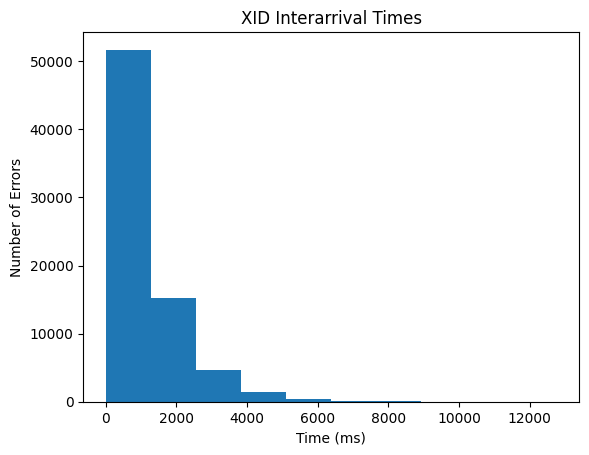

Mean interarrival time: 1054.4875208708004 milliseconds
,Interarrival time standard deviation: 1061.6803206987288 milliseconds
,Someone could run a program for an average of 1.0544875208708004 seconds before an XID error occurs.


In [ ]:
interarrivaltimes = np.diff(df.loc[:]['Timestamp']) # creates a list of the time differences between consecutive errors
plt.hist(interarrivaltimes) # create a histogram
plt.xlabel("Time (ms)")
plt.ylabel("Number of Errors")
plt.title('XID Interarrival Times')
plt.show()

print("Mean interarrival time:", np.mean(interarrivaltimes), "milliseconds") # print the mean
print("Interarrival time standard deviation:", np.std(interarrivaltimes), "milliseconds") # print the standard deviation
print("Someone could run a program for an average of", np.mean(interarrivaltimes)/1000, "seconds before an XID error occurs.")

Task 1 - 6

In [ ]:
res_exp = stats.goodness_of_fit(stats.expon, interarrivaltimes, n_mc_samples=500, statistic='ks') # calculate how well 500 samples fit an exponential distribution
print(f"Exponential Test Statistic: {res_exp.statistic}")
print(f"Exponential P-value: {res_exp.pvalue}")
res_normal = stats.goodness_of_fit(stats.norm, interarrivaltimes, n_mc_samples=500, statistic='ks') # calculate how well 500 samples fit a normal distribution
print(f"Normal Test Statistic: {res_normal.statistic}")
print(f"Normal P-value: {res_normal.pvalue}")
res_uniform = stats.goodness_of_fit(stats.uniform, interarrivaltimes, n_mc_samples=500, statistic='ks') # calculate how well 500 samples fit an uniform distribution
print(f"Uniform Test Statistic: {res_uniform.statistic}")
print(f"Uniform P-value: {res_uniform.pvalue}")
res_lognorm = stats.goodness_of_fit(stats.lognorm, interarrivaltimes, known_params={'loc': 0}, n_mc_samples=500, statistic='ks') # calculate how well 500 samples fit a lognormal distribution
print(f"Lognormal Test Statistic: {res_lognorm.statistic}")
print(f"Lognormal P-value: {res_lognorm.pvalue}")

Exponential Test Statistic: 0.0027587078476603577
,Exponential P-value: 0.3932135728542914
,Normal Test Statistic: 0.160304403757268
,Normal P-value: 0.001996007984031936
,Uniform Test Statistic: 0.7107835116555101
,Uniform P-value: 0.001996007984031936
,Lognormal Test Statistic: 0.07109998037689785
,Lognormal P-value: 0.001996007984031936


Task 1 - 7

In [ ]:
lambda_hour = 3600000 / np.mean(interarrivaltimes) #60S*60=3600, converting by millisec to seconds resulted in 3600000/the mean interarrival time
print("Poisson lambda for one hour =", lambda_hour)

Poisson lambda for one hour = 3413.9806576630745
